# Exploratory Data Analysis

In [ ]:
# Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
df = pd.read_csv("data.csv")
df.head

<bound method NDFrame.head of        Student_ID Major_Category Year_of_Study  Pre_Semester_GPA  \
0          100001     Humanities        Senior             2.418   
1          100002        Medical        Junior             3.821   
2          100003       Business      Freshman             3.398   
3          100004       Business        Senior             3.789   
4          100005           STEM     Sophomore             3.635   
...           ...            ...           ...               ...   
49995      149996       Business        Senior             2.899   
49996      149997           STEM        Senior             2.870   
49997      149998       Business        Senior             3.177   
49998      149999       Business        Junior             3.398   
49999      150000           Arts     Sophomore             3.242   

       Weekly_GenAI_Hours           Primary_Use_Case Prompt_Engineering_Skill  \
0                   23.31       Copywriting/Drafting                 Beg

# Data cleaning

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  50000 non-null  int64  
 1   Major_Category              50000 non-null  object 
 2   Year_of_Study               50000 non-null  object 
 3   Pre_Semester_GPA            50000 non-null  float64
 4   Weekly_GenAI_Hours          50000 non-null  float64
 5   Primary_Use_Case            50000 non-null  object 
 6   Prompt_Engineering_Skill    50000 non-null  object 
 7   Tool_Diversity              50000 non-null  int64  
 8   Paid_Subscription           50000 non-null  bool   
 9   Traditional_Study_Hours     50000 non-null  float64
 10  Perceived_AI_Dependency     50000 non-null  int64  
 11  Institutional_Policy        50000 non-null  object 
 12  Anxiety_Level_During_Exams  50000 non-null  int64  
 13  Post_Semester_GPA           500

### Missing values & duplicates

In [10]:
# Missing values per column
df.isnull().sum()

Student_ID                    0
Major_Category                0
Year_of_Study                 0
Pre_Semester_GPA              0
Weekly_GenAI_Hours            0
Primary_Use_Case              0
Prompt_Engineering_Skill      0
Tool_Diversity                0
Paid_Subscription             0
Traditional_Study_Hours       0
Perceived_AI_Dependency       0
Institutional_Policy          0
Anxiety_Level_During_Exams    0
Post_Semester_GPA             0
Skill_Retention_Score         0
Burnout_Risk_Level            0
dtype: int64

In [11]:
# Duplicate rows and duplicate Student_IDs
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate Student_IDs:", df['Student_ID'].duplicated().sum())

Duplicate rows: 0
Duplicate Student_IDs: 0


### Range & validity checks

In [12]:
# GPA columns should be within 0-4
print(df[['Pre_Semester_GPA', 'Post_Semester_GPA']].describe())

invalid_pre_gpa = df[(df['Pre_Semester_GPA'] < 0) | (df['Pre_Semester_GPA'] > 4)]
invalid_post_gpa = df[(df['Post_Semester_GPA'] < 0) | (df['Post_Semester_GPA'] > 4)]
print("Invalid Pre_Semester_GPA rows:", len(invalid_pre_gpa))
print("Invalid Post_Semester_GPA rows:", len(invalid_post_gpa))

       Pre_Semester_GPA  Post_Semester_GPA
count      50000.000000       50000.000000
mean           3.146102           3.349299
std            0.478854           0.495673
min            1.183000           1.000000
25%            2.834000           3.023750
50%            3.210000           3.421000
75%            3.521000           3.749000
max            3.998000           4.000000
Invalid Pre_Semester_GPA rows: 0
Invalid Post_Semester_GPA rows: 0


In [13]:
# Hours columns shouldn't be negative or exceed 168 hours/week
print(df[['Weekly_GenAI_Hours', 'Traditional_Study_Hours']].describe())

invalid_genai_hours = df[(df['Weekly_GenAI_Hours'] < 0) | (df['Weekly_GenAI_Hours'] > 168)]
invalid_study_hours = df[(df['Traditional_Study_Hours'] < 0) | (df['Traditional_Study_Hours'] > 168)]
print("Invalid Weekly_GenAI_Hours rows:", len(invalid_genai_hours))
print("Invalid Traditional_Study_Hours rows:", len(invalid_study_hours))

       Weekly_GenAI_Hours  Traditional_Study_Hours
count        50000.000000             50000.000000
mean             8.427752                11.209271
std              8.269490                 5.156426
min              0.000000                 1.000000
25%              2.390000                 7.560000
50%              5.800000                11.180000
75%             11.720000                14.710000
max             40.000000                35.860000
Invalid Weekly_GenAI_Hours rows: 0
Invalid Traditional_Study_Hours rows: 0


In [14]:
# Skill_Retention_Score should be within 0-100
print(df['Skill_Retention_Score'].describe())

invalid_retention = df[(df['Skill_Retention_Score'] < 0) | (df['Skill_Retention_Score'] > 100)]
print("Invalid Skill_Retention_Score rows:", len(invalid_retention))

count    50000.000000
mean        75.798125
std         13.281626
min         10.780000
25%         66.820000
50%         76.000000
75%         85.190000
max        100.000000
Name: Skill_Retention_Score, dtype: float64
Invalid Skill_Retention_Score rows: 0


In [15]:
# Check the value range of scale/rating columns
for col in ['Tool_Diversity', 'Perceived_AI_Dependency', 'Anxiety_Level_During_Exams']:
    print(col, "->", sorted(df[col].unique()))

Tool_Diversity -> [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
Perceived_AI_Dependency -> [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]
Anxiety_Level_During_Exams -> [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]


### Categorical consistency checks

In [16]:
# Check for unexpected values, typos, or inconsistent casing in categorical columns
categorical_cols = ['Major_Category', 'Year_of_Study', 'Primary_Use_Case',
                     'Prompt_Engineering_Skill', 'Institutional_Policy', 'Burnout_Risk_Level']

for col in categorical_cols:
    print(col, "->", df[col].unique())

Major_Category -> ['Humanities' 'Medical' 'Business' 'STEM' 'Arts']
Year_of_Study -> ['Senior' 'Junior' 'Freshman' 'Sophomore' 'Graduate']
Primary_Use_Case -> ['Copywriting/Drafting' 'Ideation' 'Summarizing_Reading'
 'Debugging/Troubleshooting' 'Direct_Answer_Generation']
Prompt_Engineering_Skill -> ['Beginner' 'Advanced' 'Intermediate']
Institutional_Policy -> ['Allowed_With_Citation' 'Strict_Ban' 'Actively_Encouraged']
Burnout_Risk_Level -> ['High' 'Low' 'Medium']


### Dtype conversions

In [17]:
# Plain categoricals
for col in ['Major_Category', 'Primary_Use_Case', 'Institutional_Policy']:
    df[col] = df[col].astype('category')

# Ordered categoricals
df['Year_of_Study'] = pd.Categorical(df['Year_of_Study'],
    categories=['Freshman', 'Sophomore', 'Junior', 'Senior', 'Graduate'], ordered=True)

df['Prompt_Engineering_Skill'] = pd.Categorical(df['Prompt_Engineering_Skill'],
    categories=['Beginner', 'Intermediate', 'Advanced'], ordered=True)

df['Burnout_Risk_Level'] = pd.Categorical(df['Burnout_Risk_Level'],
    categories=['Low', 'Medium', 'High'], ordered=True)

df.dtypes

Student_ID                       int64
Major_Category                category
Year_of_Study                 category
Pre_Semester_GPA               float64
Weekly_GenAI_Hours             float64
Primary_Use_Case              category
Prompt_Engineering_Skill      category
Tool_Diversity                   int64
Paid_Subscription                 bool
Traditional_Study_Hours        float64
Perceived_AI_Dependency          int64
Institutional_Policy          category
Anxiety_Level_During_Exams       int64
Post_Semester_GPA              float64
Skill_Retention_Score          float64
Burnout_Risk_Level            category
dtype: object

# Usage Patterns

## Distributions

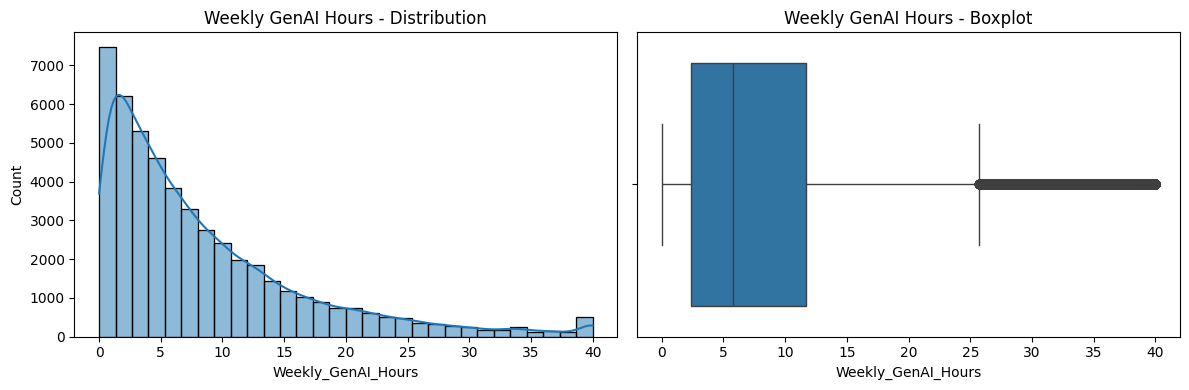

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df['Weekly_GenAI_Hours'], bins=30, kde=True, ax=axes[0])
axes[0].set_title('Weekly GenAI Hours - Distribution')

sns.boxplot(x=df['Weekly_GenAI_Hours'], ax=axes[1])
axes[1].set_title('Weekly GenAI Hours - Boxplot')

plt.tight_layout()
plt.show()

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df['Tool_Diversity'], bins=5, kde=False, ax=axes[0])
axes[0].set_title('Tool Diversity - Distribution')

sns.boxplot(x=df['Tool_Diversity'], ax=axes[1])
axes[1].set_title('Tool Diversity - Boxplot')

plt.tight_layout()
plt.show()

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df['Traditional_Study_Hours'], bins=30, kde=True, ax=axes[0])
axes[0].set_title('Traditional Study Hours - Distribution')

sns.boxplot(x=df['Traditional_Study_Hours'], ax=axes[1])
axes[1].set_title('Traditional Study Hours - Boxplot')

plt.tight_layout()
plt.show()

## Major Category vs Primary Use Case

In [ ]:
# Cross-tab: counts of Primary_Use_Case per Major_Category
cross_tab = pd.crosstab(df['Major_Category'], df['Primary_Use_Case'])
cross_tab

In [ ]:
# Normalize by row so each Major_Category sums to 100% - easier to compare proportions across majors
cross_tab_pct = pd.crosstab(df['Major_Category'], df['Primary_Use_Case'], normalize='index') * 100

plt.figure(figsize=(10, 6))
sns.heatmap(cross_tab_pct, annot=True, fmt='.1f', cmap='Blues')
plt.title('Primary Use Case by Major Category (% within each Major)')
plt.ylabel('Major Category')
plt.xlabel('Primary Use Case')
plt.tight_layout()
plt.show()

## Prompt Engineering Skill vs Year of Study

In [ ]:
# Cross-tab: counts of Prompt_Engineering_Skill per Year_of_Study
skill_by_year = pd.crosstab(df['Year_of_Study'], df['Prompt_Engineering_Skill'])
skill_by_year

In [ ]:
# Normalize by row so each Year_of_Study sums to 100% - shows skill progression across years
skill_by_year_pct = pd.crosstab(df['Year_of_Study'], df['Prompt_Engineering_Skill'], normalize='index') * 100

skill_by_year_pct.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='Blues')
plt.title('Prompt Engineering Skill by Year of Study (%)')
plt.ylabel('Percentage')
plt.xlabel('Year of Study')
plt.legend(title='Prompt Engineering Skill')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Institutional Policy vs Weekly GenAI Hours

In [ ]:
# Summary stats of Weekly_GenAI_Hours grouped by Institutional_Policy
df.groupby('Institutional_Policy')['Weekly_GenAI_Hours'].describe()

In [ ]:
# Boxplot: does GenAI usage differ by institutional policy?
plt.figure(figsize=(8, 5))
sns.boxplot(x='Institutional_Policy', y='Weekly_GenAI_Hours', data=df,
            order=['Strict_Ban', 'Allowed_With_Citation', 'Actively_Encouraged'])
plt.title('Weekly GenAI Hours by Institutional Policy')
plt.xlabel('Institutional Policy')
plt.ylabel('Weekly GenAI Hours')
plt.tight_layout()
plt.show()

## Paid Subscription vs Tool Diversity / Weekly GenAI Hours

In [ ]:
# Summary stats grouped by Paid_Subscription
df.groupby('Paid_Subscription')[['Tool_Diversity', 'Weekly_GenAI_Hours']].describe()

In [ ]:
# Do paid users use AI more, and more diversely?
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(x='Paid_Subscription', y='Tool_Diversity', data=df, ax=axes[0])
axes[0].set_title('Tool Diversity by Paid Subscription')

sns.boxplot(x='Paid_Subscription', y='Weekly_GenAI_Hours', data=df, ax=axes[1])
axes[1].set_title('Weekly GenAI Hours by Paid Subscription')

plt.tight_layout()
plt.show()

## Observations - Usage Patterns

- **Weekly GenAI Hours**: Most students (~70%) use GenAI tools for 0-10 hours/week, with a long right tail — a smaller group of heavy users exceeds 25 hours/week (flagged as statistical outliers).
- **Tool Diversity**: Students use on average ~2.8 distinct AI tools (median 3), suggesting most students rely on a small handful of tools rather than one or many.
- **Traditional Study Hours**: Averages ~11 hours/week, roughly comparable in magnitude to GenAI usage for heavy users.
- **Primary Use Case by Major**: Each major has a clear dominant use case — STEM leans toward Debugging/Troubleshooting, Arts and Humanities toward Copywriting/Drafting, Business toward Ideation, and Medical toward Summarizing/Reading. This suggests AI usage is shaped by the nature of coursework in each field.
- **Prompt Engineering Skill by Year of Study**: Skill level distribution (Beginner/Intermediate/Advanced) is nearly identical across Freshman through Graduate. Skill does not appear to improve with academic seniority, which is somewhat unexpected.
- **Institutional Policy vs Usage**: Weekly GenAI hours are nearly the same regardless of whether a school's policy is Strict_Ban, Allowed_With_Citation, or Actively_Encouraged. Policy does not appear to meaningfully affect how much students actually use AI.
- **Paid Subscription**: Tool diversity is essentially the same between paid and unpaid users, but paid subscribers spend noticeably more time using GenAI (median ~7.6 hrs/week vs ~4.9 hrs/week for unpaid).

**Open questions for joint synthesis**: Does the lack of skill progression by year, or the lack of policy effect on usage, correlate with anything in the outcomes/well-being data (GPA change, burnout, anxiety)?